In [ ]:
# Notch Filter

In [1]:
import pandas as pd 
import os
import matplotlib.pyplot as plt
import numpy as np
import mne

Creating RawArray with float64 data, n_channels=14, n_times=2736
    Range : 0 ... 2735 =      0.000 ...    21.367 secs
Ready.


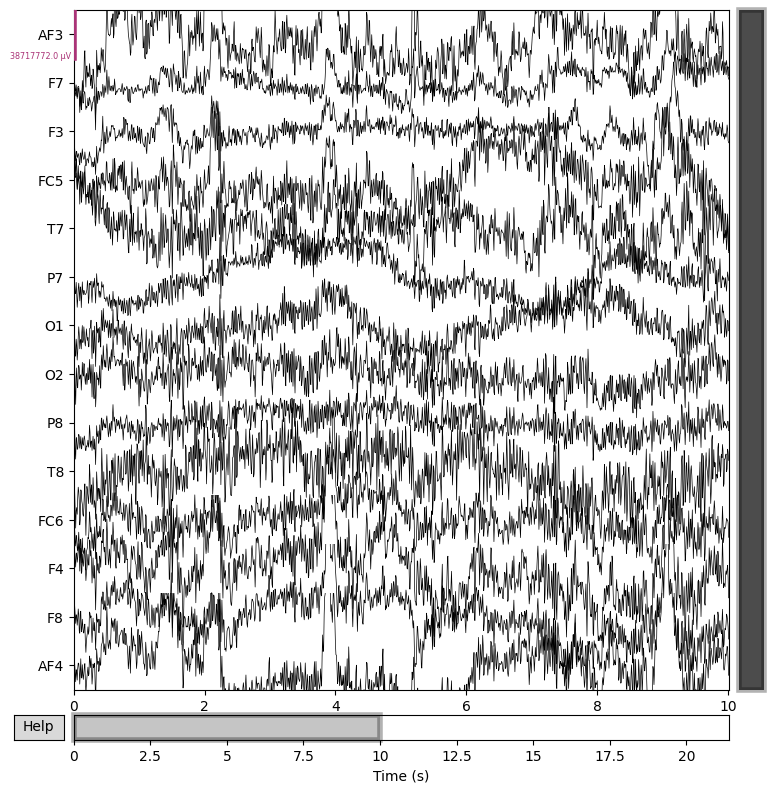

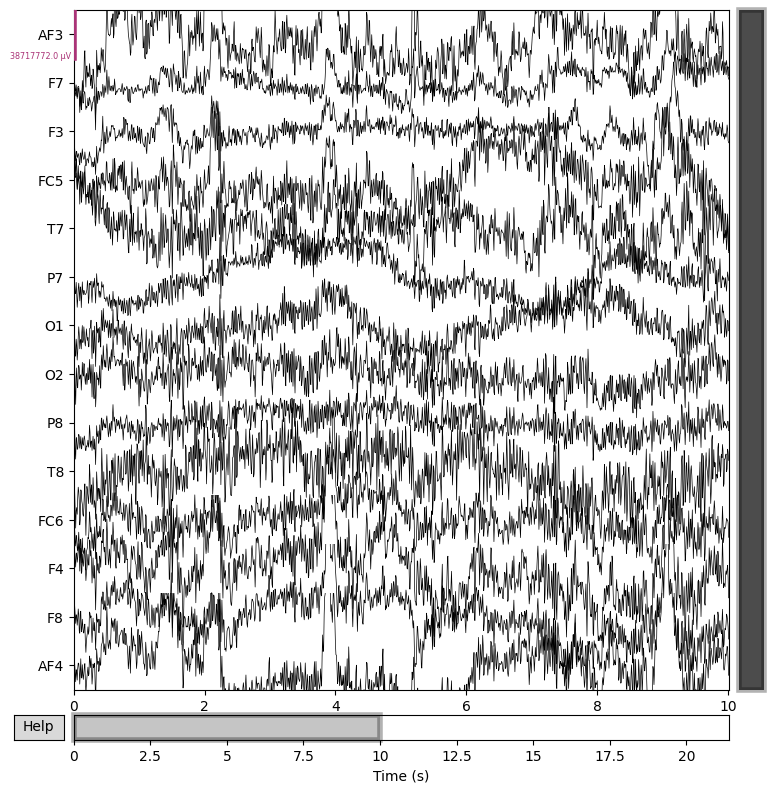

In [30]:
# import the data 

SFREQ = 128 #Hz
CH_NAMES = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']


# path = '../data/raw/raw_eeg_id_07-20250210T171013Z-001/raw_eeg_id_07/raw_eeg_allegra_left_EPOCX_268904_2025.02.10T11.11.31.05.00.md.mc.pm.fe.bp.csv'
# df = pd.read_csv(path,header = 1)
df = pd.read_csv('../data/raw/raw_eeg_allegra_right_EPOCX_268904_2025.02.10T11.12.22.05.00.md.mc.pm.fe.bp.csv', header=1)


eeg_columns = [ 'EEG.AF3','EEG.F7','EEG.F3','EEG.FC5','EEG.T7','EEG.P7','EEG.O1',
                'EEG.O2','EEG.P8','EEG.T8', 'EEG.FC6','EEG.F4','EEG.F8','EEG.AF4']

df_eeg = df[eeg_columns]

# import into mne (https://stackoverflow.com/questions/63172453/python-read-eeg-data-form-csv-file-using-mne)
info = mne.create_info(ch_names = CH_NAMES, sfreq = SFREQ, ch_types='eeg')
raw = mne.io.RawArray(df_eeg.transpose(), info)

raw.plot(scalings = "auto", proj=False, n_channels=len(raw.ch_names))


Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


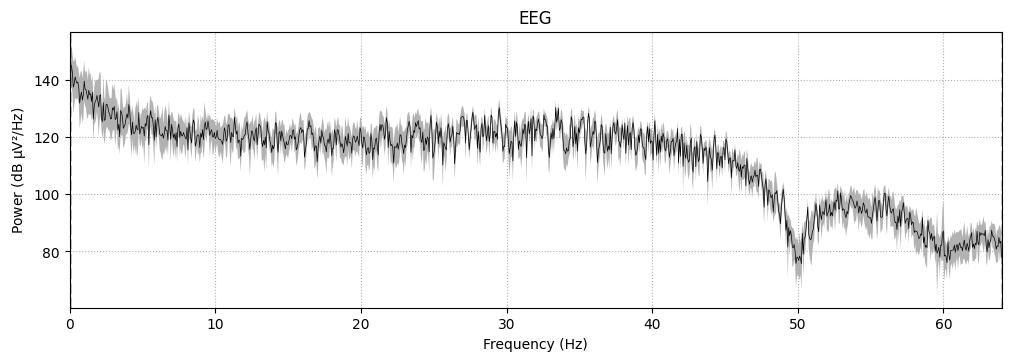

In [31]:
def add_arrows(axes):
    """Add some arrows at 60 Hz and its harmonics."""
    for ax in axes:
        freqs = ax.lines[-1].get_xdata()
        psds = ax.lines[-1].get_ydata()
        for freq in (60, 120, 180, 240):
            idx = np.searchsorted(freqs, freq)
            # get ymax of a small region around the freq. of interest
            y = psds[(idx - 4) : (idx + 5)].max()
            ax.arrow(
                x=freqs[idx],
                y=y + 18,
                dx=0,
                dy=-12,
                color="red",
                width=0.1,
                head_width=3,
                length_includes_head=True,
            )


raw.compute_psd(fmax=64).plot(
    average=True, amplitude=False, picks=raw.ch_names, exclude="bads"
)
# add_arrows(fig.axes[:2])

plt.show()


In [32]:
def filter(raw,start,stop):
    raw_copy = raw.copy()
    filtered_eeg = raw_copy.filter(start,stop, picks='eeg')
    return filtered_eeg

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 12 - 22 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 12.00
- Lower transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 10.50 Hz)
- Upper passband edge: 22.00 Hz
- Upper transition bandwidth: 5.50 Hz (-6 dB cutoff frequency: 24.75 Hz)
- Filter length: 141 samples (1.102 s)



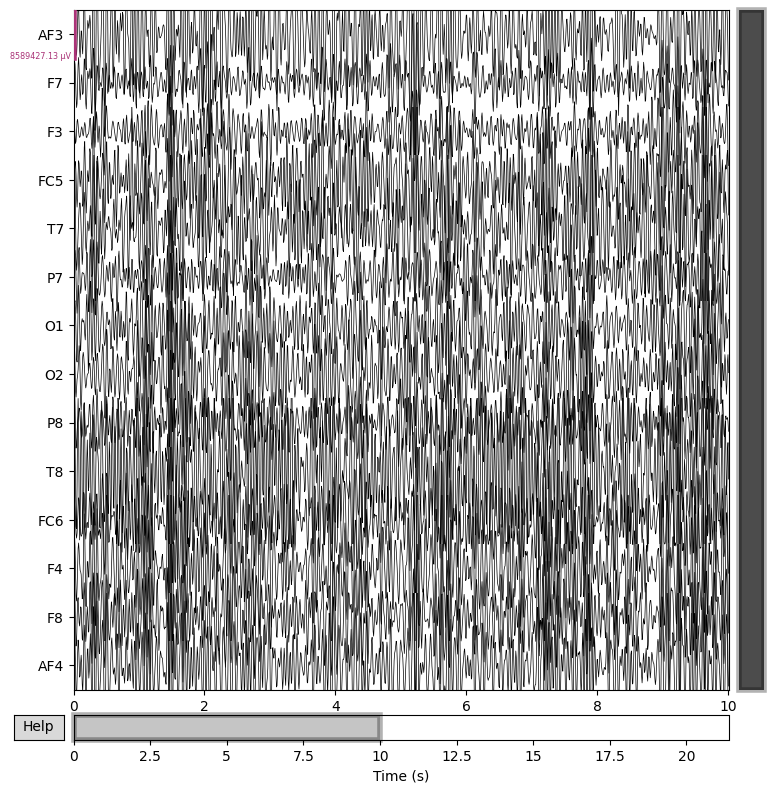

In [33]:
beta_waves = filter(raw,12,22)
beta_waves.plot(scalings = "auto")
plt.show()

In [48]:
psd = beta_waves.compute_psd()
# plt.show()

Effective window size : 16.000 (s)


In [ ]:
psd.freqs
# freqs

array([0.00000e+00, 6.25000e-02, 1.25000e-01, ..., 6.38750e+01,
       6.39375e+01, 6.40000e+01], shape=(1025,))

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 213 samples (1.664 s)



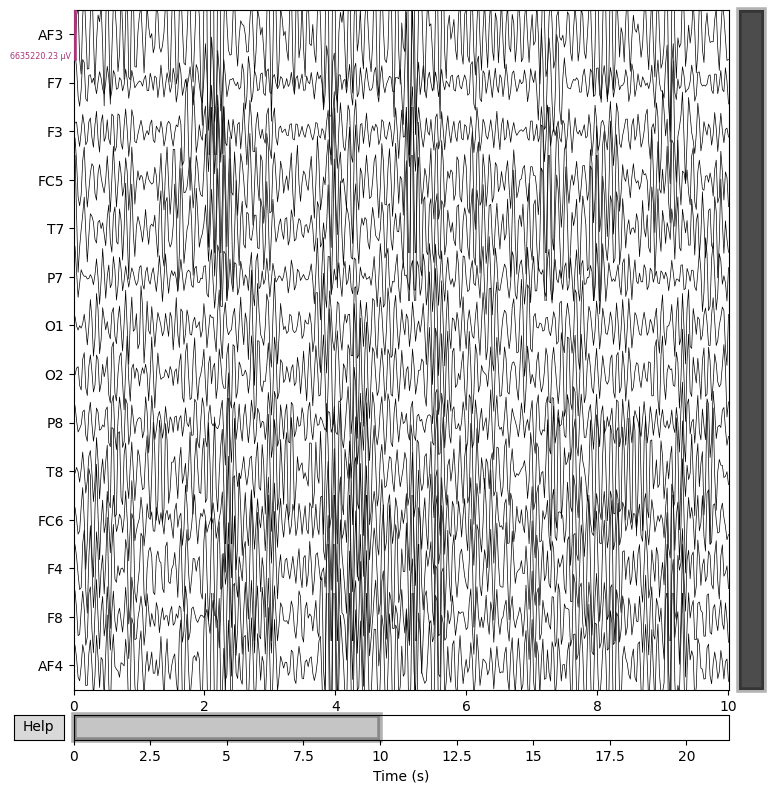

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


C:\Users\lizoc\AppData\Local\Temp\ipykernel_33964\857393117.py:4: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  alpha_waves.compute_psd().plot()
C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


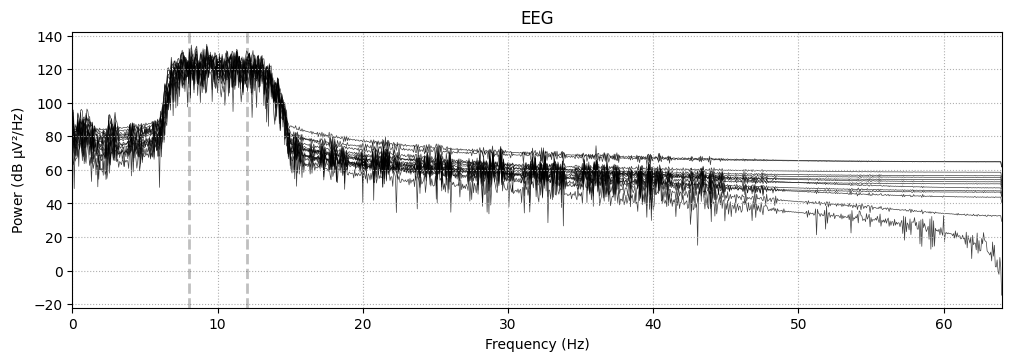

In [ ]:
alpha_waves = filter(raw, 8, 12)
alpha_waves.plot(scalings = "auto")
plt.show()
alpha_waves.compute_psd().plot()
plt.show()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 213 samples (1.664 s)



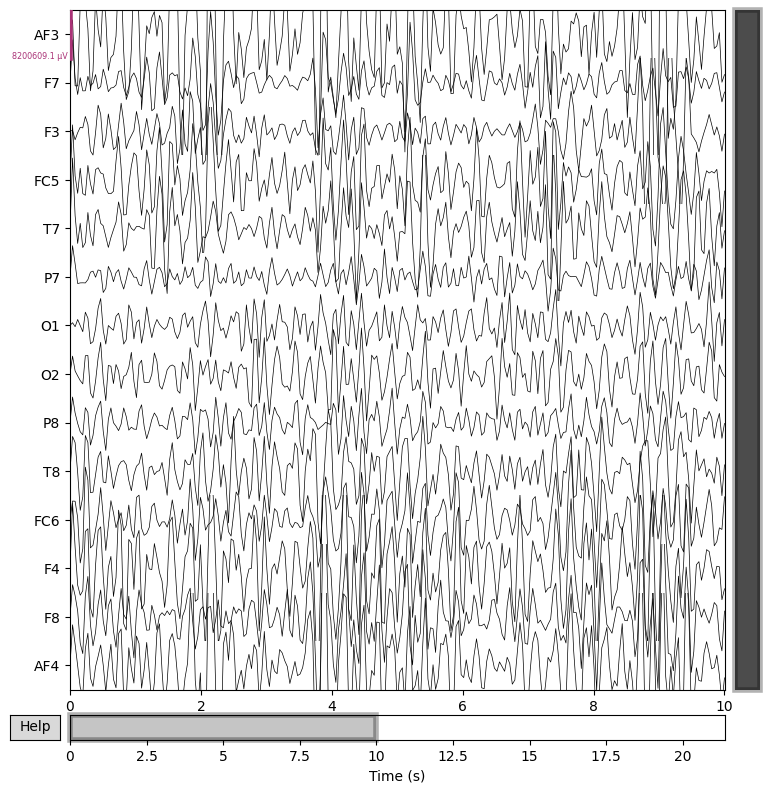

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


C:\Users\lizoc\AppData\Local\Temp\ipykernel_33964\1806095390.py:4: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  theta_waves.compute_psd().plot()
C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


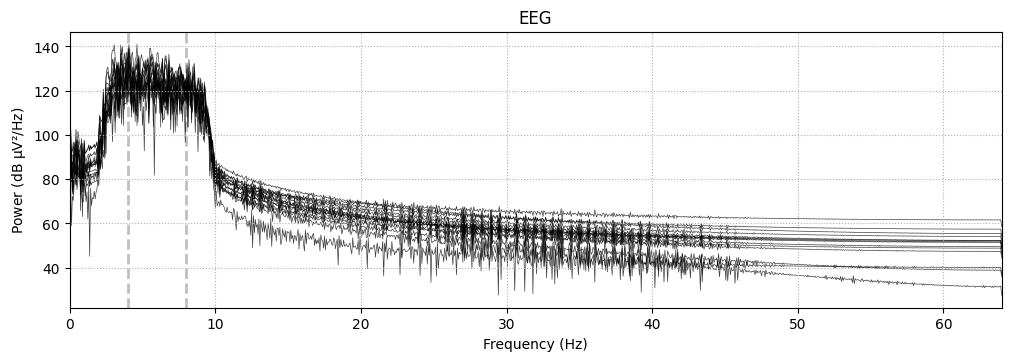

In [43]:
theta_waves = filter(raw,4,8)
theta_waves.plot(scalings = "auto")
plt.show()
theta_waves.compute_psd().plot()
plt.show()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 423 samples (3.305 s)



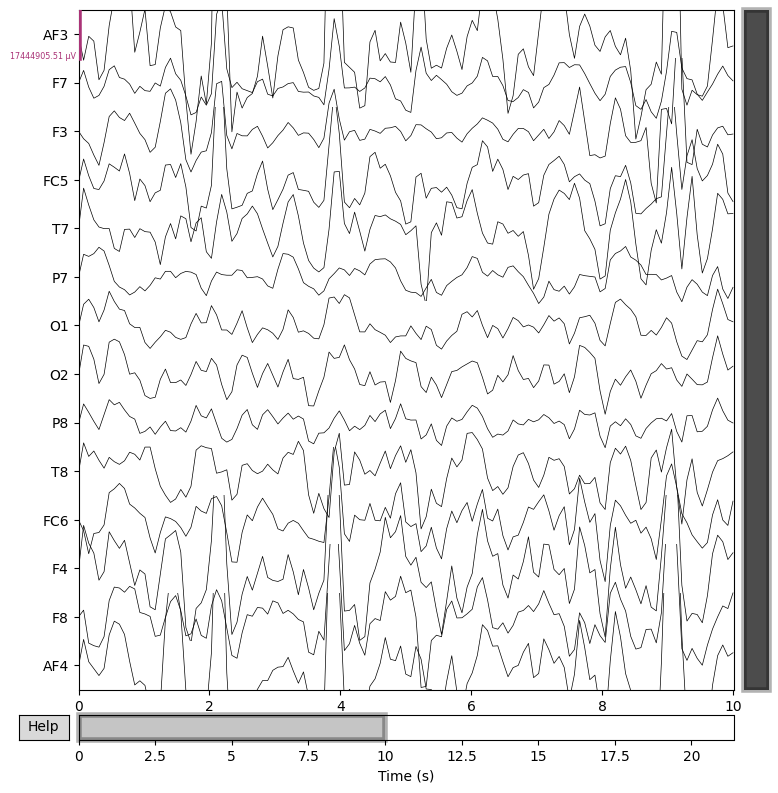

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


C:\Users\lizoc\AppData\Local\Temp\ipykernel_33964\2458250517.py:4: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  delta_waves.compute_psd().plot()
C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


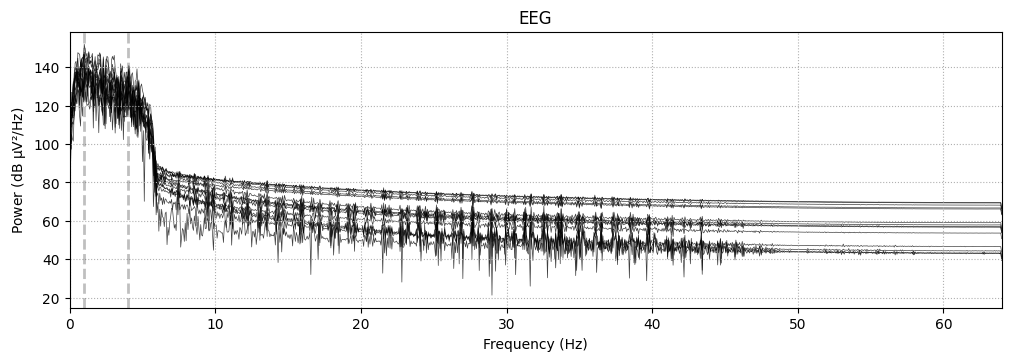

In [44]:
delta_waves = filter(raw,1,4)
delta_waves.plot(scalings = "auto")
plt.show()
delta_waves.compute_psd().plot()

### bandpower

In [ ]:
# https://mne.discourse.group/t/calculate-psd-using-compute-psd-and-extracting-them/9034

# this creates an average power per channel 
def bandpower(psd, freqs, band):
    band_freqs = np.logical_and(freqs >= band[0], freqs <= band[1])
    band_power = np.mean(psd[:, :, band_freqs], axis=-1) # averaging across all epochs 
    # psd --> [number of epochs, n_channels, n_time_points]
    return np.mean(band_power, axis=0) # averages across all epochs 

In [53]:
beta_waves = filter(raw,12,22)
b_psd = beta_waves.compute_psd()
freqs = b_psd.freqs
psd_data = b_psd.data

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 12 - 22 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 12.00
- Lower transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 10.50 Hz)
- Upper passband edge: 22.00 Hz
- Upper transition bandwidth: 5.50 Hz (-6 dB cutoff frequency: 24.75 Hz)
- Filter length: 141 samples (1.102 s)

Effective window size : 16.000 (s)


In [70]:
freqs

array([0.00000e+00, 6.25000e-02, 1.25000e-01, ..., 6.38750e+01,
       6.39375e+01, 6.40000e+01], shape=(1025,))

In [ ]:
band_power = bandpower(np.expand_dims(psd_data, axis=0), freqs, (12, 20))
band_power.shape


(14,)

In [61]:
bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30)
}

In [ ]:
a = raw.compute_psd()
freqs = a.freqs # frequencies 
psd_data = a.data # power at each frequency

Effective window size : 16.000 (s)


In [67]:
band_powers = {band: bandpower(np.expand_dims(psd_data, axis=0), freqs, bands[band]) for band in bands}

In [ ]:
fig, ax = plt.subplots()
bands_names = list(band_powers.keys())
mean_powers = [np.mean(band_powers[band]) for band in bands_names] # averages across all channels giving you a singular value 

ax.bar(bands_names, mean_powers)
ax.set_xlabel('Frequency Bands')
ax.set_ylabel('Mean Power (dB μV²/Hz)')
ax.set_title('Mean Power in Different Frequency Bands')

Text(0.5, 1.0, 'Mean Power in Different Frequency Bands')

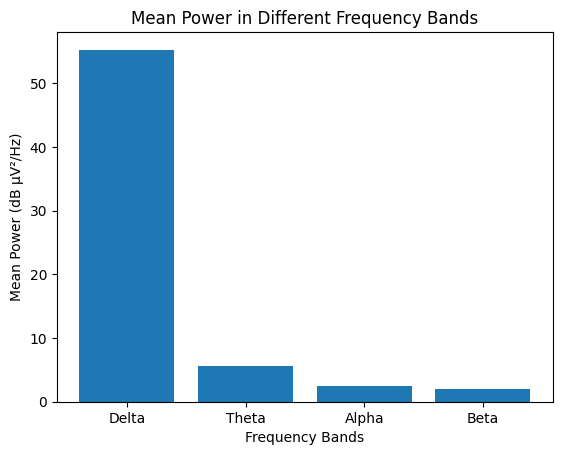

In [69]:
plt.show()

In [74]:
band_powers

{'Delta': array([262.3392171 ,  13.33422242,  16.11275981,  29.16790257,
         31.77141687,  55.84477069,   9.78134426,   6.95060854,
          3.54408465,  31.77984387,  24.56648649,  81.33829058,
         65.85446229, 141.04205411]),
 'Theta': array([21.93758992,  1.41232581,  3.09658022,  3.76074758,  3.45930562,
         0.99574281,  1.28479013,  2.40741575,  1.09162484,  2.30766597,
         4.08602407, 10.56526957,  7.28590584, 13.71448363]),
 'Alpha': array([5.28067322, 0.92618259, 0.71488153, 2.62928686, 2.99611413,
        0.83979182, 1.4293412 , 1.97387664, 1.05924805, 3.5563135 ,
        2.05400342, 3.78254128, 2.46057133, 4.08595255]),
 'Beta': array([2.69552887, 0.61033893, 0.63641633, 2.96160297, 2.77382878,
        0.9437321 , 1.66644585, 1.91852499, 1.30552234, 4.68418336,
        1.79188302, 2.94611546, 1.66507986, 2.35586781])}

In [76]:
# to calcuate the ratio just divide the values 
mean_power_dict = {band: np.mean(band_powers[band]) for band in bands_names} # averages across all channels giving you a singular value 



relax_or_active = mean_power_dict['Alpha'] / mean_power_dict['Beta']

cognitive_control = mean_power_dict['Theta'] / mean_power_dict['Beta']

print(relax_or_active)
print(cognitive_control)

1.166938202764616
2.6732959013607918
